<a href="https://colab.research.google.com/github/mailinh21042005-rgb/Asteroids_Game/blob/main/Rice_leaf_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import zipfile
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time
from PIL import Image
from google.colab import data_table
from sklearn.model_selection import train_test_split
from PIL import Image
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from skimage import color, exposure, feature
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import seaborn as sns
import joblib  # for loading saved features (if used)
import warnings
warnings.filterwarnings('ignore')

FILE_ID = "1RmJbTZ1bPP7JvKomxG4Yp5QhxH5KsTRM"
def download_dataset(file_id):
    if os.path.exists("data_downloaded.zip"):
        os.remove("data_downloaded.zip")
    print(f">>> Đang tải dữ liệu từ ID: {file_id} ...")

    try:
        os.system("pip install --upgrade --quiet gdown")
        exit_code = os.system(f'gdown --id {file_id} -O data_downloaded.zip --fuzzy')

        # Kiểm tra file
        if os.path.exists("data_downloaded.zip") and os.path.getsize("data_downloaded.zip") > 1000:
            print(">>> Tải xong! Đang giải nén...")
            with zipfile.ZipFile("data_downloaded.zip", 'r') as zip_ref:
                zip_ref.extractall("dataset_folder")
            print(">>> Giải nén thành công!")
            return True
        else:
            print("XXX LỖI: Tải thất bại (File quá nhỏ hoặc không tồn tại).")
            print("=> Hãy kiểm tra lại quyền chia sẻ 'Anyone with the link' của file.")
            return False
    except Exception as e:
        print(f"Lỗi hệ thống: {e}")
        return False

if download_dataset(FILE_ID):
    data = []
    metadata = []
    class_names = []

    root = "dataset_folder"
    print(f"\n>>> Đang quét ảnh trong thư mục giải nén...")

    for current_path, dirs, files in os.walk(root):
        images = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

        if len(images) > 0:
            folder_name = os.path.basename(current_path)

            if folder_name.startswith(".") or folder_name.startswith("__"):
                continue

            if folder_name not in class_names:
                class_names.append(folder_name)

            class_idx = class_names.index(folder_name)

            for fname in images:
                try:
                    fpath = os.path.join(current_path, fname)
                    # Đọc ảnh
                    img = Image.open(fpath)
                    arr = np.array(img)

                    data.append(arr)
                    metadata.append({
                        "File Name": fname,
                        "Class Name": folder_name,
                        "Label ID": class_idx
                    })
                except:
                    pass

# In kết quả
    # data = np.array(data)

    if len(data) > 0:
        print(f"\n=> TỔNG SỐ ẢNH TÌM THẤY: {len(data)}")

        df = pd.DataFrame(metadata)
        df = df.sort_values("Class Name") # Sắp xếp theo tên lớp
    else:
        print("❌ Cảnh báo: File zip giải nén thành công nhưng không tìm thấy ảnh nào bên trong.")

>>> Đang tải dữ liệu từ ID: 1RmJbTZ1bPP7JvKomxG4Yp5QhxH5KsTRM ...
>>> Tải xong! Đang giải nén...
>>> Giải nén thành công!

>>> Đang quét ảnh trong thư mục giải nén...

=> TỔNG SỐ ẢNH TÌM THẤY: 120


**Giải thích cell 1: cài thư viện và nhập dữ liệu**
- Dòng 1 -> 11: thực hiện import các thư viện cần thiết để sử dụng.
- Dòng 13: lưu đường dẫn Google Drive của tệp zip vào biến FILE_ID.
- Dòng 14 -> 16: thực hiện tải bộ dataset download_dataset(file_id) (trong quá trình tải sẽ kiểm tra nếu có tệp ZIP cũ tồn tại sẽ xóa đi để tải lại file mới).
- Dòng 17, 20: in ra thông báo.
- Dòng 19: cài gdown và sử dụng nó để tải file zip từ Google Drive.
- Dòng 23 -> 25: Dùng điều kiện if để kiểm tra data_downloaded.zip, nếu file đưa ra kết quả > 1KB thì tiếp tục chương trình.
- Dòng 26 -> 28: giải nén tệp zip vừa tải và thư mục dataser_folder qua câu lệnh zip_ref.extractall("dataset_folder").
- Dòng 31 -> 36: in ra thông báo lỗi hệ thống khi điều kiện sai
- Dòng 38 -> 41: sử dụng vòng lặp if download_dataset(FILE_ID) để đọc dữ liệu ảnh.
- Dòng 43 -> 74: duyệt thư mục dataset và gắn label ID cho từng lớp.
- Dòng 47: dùng vòng lặp for để duyệt toàn bộ thư mục rồi trích xuất các file ảnh hợp lệ (các file ảnh có đuôi '.jpg', '.jpeg', '.png', '.bmp').
- Dòng 50: đặt tên lớp bằng cách sử dụng tên của các thư mục con qua lệnh folder_name = os.path.basename(current_path).
- Dòng 52 -> 58: dùng điều kiện if để kiểm tra xem folder_name có tên trong danh sách chưa, nếu chưa thì thêm vào.
- Dòng 60 -> 74: đọc ảnh trong thư mục rồi lưu vào metadata
- Dòng 77 -> 85: in ra tổng số ảnh đọc được.

In [ ]:
# Mô tả dữ liệu
if len(metadata) > 0:
    # Tạo DataFrame từ metadata
    df = pd.DataFrame(metadata)

    # Nội dung giải thích ý nghĩa
    meaning_text = (
        "Dữ liệu gồm 3 loại bệnh lúa chính:\n"
        "1. Bacterial leaf blight: Bệnh cháy bìa lá (Bạc lá) do vi khuẩn.\n"
        "2. Brown spot: Bệnh đốm nâu do nấm.\n"
        "3. Leaf smut: Bệnh than đen (đen lép hạt) do nấm."
    )

    # Chuẩn bị dữ liệu cho bảng
    desc_data = {
        "Mô tả dữ liệu (Criteria)": [
            "Số mẫu (Rows)",
            "Số thuộc tính (Columns)",
            "Tên biến mục tiêu (Label)",
            "Loại dữ liệu",
            "Số lượng lớp (Classes)",
            "Danh sách các lớp",
            "Giải thích ý nghĩa các lớp"
        ],
        "Giá trị (Values)": [
            f"{len(df)} ảnh",
            f"{("Height, Width, Channels")}",
            "Class Name",
            "Image",
            f"{len(class_names)} lớp",
            ", ".join(class_names),
            meaning_text
        ]
    }

    df_desc = pd.DataFrame(desc_data)

    print("\n" + "="*40)
    print(">>> BẢNG MÔ TẢ DỮ LIỆU")
    print("="*40)

    # Định dạng bảng: Ẩn index, căn lề trái, xuống dòng tự động
    styled_table = df_desc.style.hide(axis='index').set_properties(**{
        'text-align': 'left',
        'white-space': 'pre-wrap',
        'vertical-align': 'top'
    })

    # Hiển thị bảng
    display(styled_table)

else:
    print("❌ Cảnh báo: File zip giải nén thành công nhưng không tìm thấy ảnh nào bên trong.")


>>> BẢNG MÔ TẢ DỮ LIỆU


Mô tả dữ liệu (Criteria),Giá trị (Values)
Số mẫu (Rows),120 ảnh
Số thuộc tính (Columns),"Height, Width, Channels"
Tên biến mục tiêu (Label),Class Name
Loại dữ liệu,Image
Số lượng lớp (Classes),3 lớp
Danh sách các lớp,"Leaf smut, Brown spot, Bacterial leaf blight"
Giải thích ý nghĩa các lớp,Dữ liệu gồm 3 loại bệnh lúa chính: 1. Bacterial leaf blight: Bệnh cháy bìa lá (Bạc lá) do vi khuẩn. 2. Brown spot: Bệnh đốm nâu do nấm. 3. Leaf smut: Bệnh than đen (đen lép hạt) do nấm.


**Giải thích cell 2: bảng dữ liệu mô tả**
- Dòng 1 -> 4: kiểm tra metadata có chứa thông tin ảnh không, nếu có thực hiện tạo data frame từ metadata vào biến df.
- Dòng 6 -> 12: giải thích ý nghĩa của từng thuộc tính
- Dòng 14 -> 34: in ra dữ liệu cần mô tả.
- Dòng 36: thực hiện định dạng 7 dòng, 2 cột.
- Dòng 38 -> 40: in tiêu đề bảng.
- Dòng 42 -> 47: định dạng format cho data frame.
- Dòng 49 -> 50: hiển thị bảng mô tả.
- Dòng 53: in ra cảnh báo nếu file zip giải nén thành công nhưng không tìm thấy ảnh.


>>> KIỂM TRA DỮ LIỆU THÔ

[A] Bảng kiểm tra Missing Values:


,Số lượng Missing,Tỷ lệ (%)
File Name,0,0.0
Class Name,0,0.0
Label ID,0,0.0
Width,0,0.0
Height,0,0.0
Mean Intensity,0,0.0



[B] Biểu đồ Outliers (Boxplot):


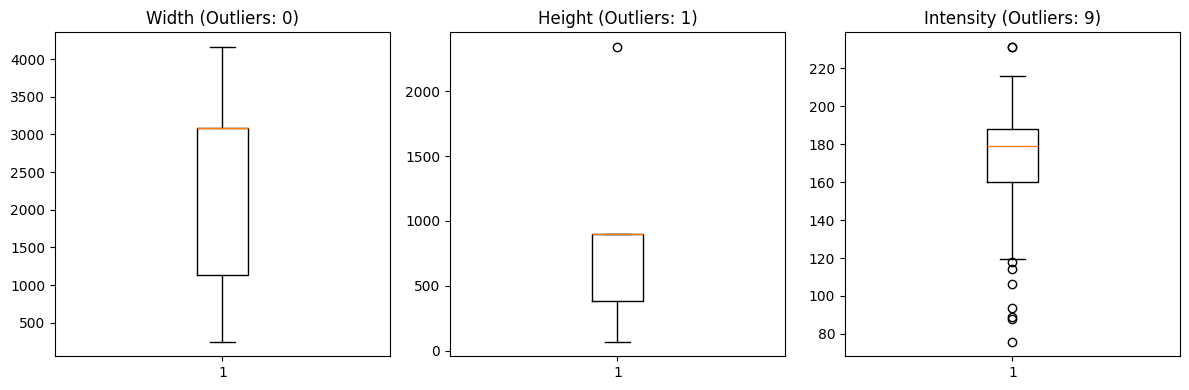


[C] KẾT LUẬN:
   o "Dataset có 0 dòng bị thiếu (missing values)."
   o "Có 1 giá trị ngoại lai ở thuộc tính 'Height' (Chiều dài ảnh không đồng nhất)."
   o "Có 9 giá trị ngoại lai ở thuộc tính 'Mean Intensity' (Ảnh quá sáng/tối)."
   o "Có 0 dòng trùng lặp đã được phát hiện."


In [ ]:
# Kiểm tra dữ liệu thô

print("\n" + "="*40)
print(">>> KIỂM TRA DỮ LIỆU THÔ")
print("="*40)

if len(data) > 0:
    widths = [img.shape[1] for img in data]      # Chiều rộng
    heights = [img.shape[0] for img in data]     # Chiều cao
    intensities = [img.mean() for img in data]   # Độ sáng trung bình

    # Thêm vào DataFrame hiện tại
    df['Width'] = widths
    df['Height'] = heights
    df['Mean Intensity'] = intensities

    # Kiểm tra missing values
    print("\n[A] Bảng kiểm tra Missing Values:")
    missing_df = pd.DataFrame(df.isnull().sum(), columns=['Số lượng Missing'])
    missing_df['Tỷ lệ (%)'] = (missing_df['Số lượng Missing'] / len(df)) * 100
    display(missing_df)

    # Kiểm tra duplicate rows
    duplicate_count = df.duplicated(subset=['File Name', 'Width', 'Height']).sum()

    # Kiểm tra outliers bằng IQR
    def count_outliers_iqr(dataframe, column):
        Q1 = dataframe[column].quantile(0.25)
        Q3 = dataframe[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Đếm số lượng giá trị nằm ngoài khoảng
        n_outliers = ((dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)).sum()
        return n_outliers

    outlier_w = count_outliers_iqr(df, 'Width')
    outlier_h = count_outliers_iqr(df, 'Height')
    outlier_i = count_outliers_iqr(df, 'Mean Intensity')

    # Vẽ biểu đồ Boxplot để chỉ ra Outliers
    print("\n[B] Biểu đồ Outliers (Boxplot):")
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.boxplot(df['Width'])
    plt.title(f'Width (Outliers: {outlier_w})')

    plt.subplot(1, 3, 2)
    plt.boxplot(df['Height'])
    plt.title(f'Height (Outliers: {outlier_h})')

    plt.subplot(1, 3, 3)
    plt.boxplot(df['Mean Intensity'])
    plt.title(f'Intensity (Outliers: {outlier_i})')

    plt.tight_layout()
    plt.show()

    # Kết luận
    print("\n[C] KẾT LUẬN:")

    # 1. Kết luận Missing
    total_missing = df.isnull().sum().sum()
    print(f"   o \"Dataset có {total_missing} dòng bị thiếu (missing values).\"")

    # 2. Kết luận Outliers
    if outlier_w > 0:
        print(f"   o \"Có {outlier_w} giá trị ngoại lai ở thuộc tính 'Width' (Chiều rộng ảnh không đồng nhất).\"")
    if outlier_h > 0:
        print(f"   o \"Có {outlier_h} giá trị ngoại lai ở thuộc tính 'Height' (Chiều dài ảnh không đồng nhất).\"")
    if outlier_i > 0:
        print(f"   o \"Có {outlier_i} giá trị ngoại lai ở thuộc tính 'Mean Intensity' (Ảnh quá sáng/tối).\"")
    if outlier_w == 0 and outlier_h == 0 and outlier_i == 0:
        print(f"   o \"Không phát hiện giá trị ngoại lai đáng kể theo phương pháp IQR.\"")

    # 3. Kết luận Duplicate
    print(f"   o \"Có {duplicate_count} dòng trùng lặp đã được phát hiện.\"")

else:
    print("Chưa có dữ liệu để kiểm tra.")

**Giải thích cell 3: kiểm tra dữ liệu thô**
- Dòng 3 -> 5: in ra thông báo kiểm tra.
- Dòng 7: kiểm tra điều kiện len(data): nếu có ảnh thì thực hiện chương trình.
- Dòng 8 -> 10: lấy thông tin cơ bản của các hình ảnh.
- Dòng 12 -> 15: gán các thông tin cơ bản vừa lấy được vào data frame hiện tại.
- Dòng 17 -> 21: tính toán kiểm tra và in ra bảng missing values.
- Dòng 23 -> 24: kiểm tra xem ảnh có bị trùng lặp không và lưu vào biến duplicate_count.
- Dòng 26 -> 36: thực hiện kiểm tra ouliers bằng phương pháp IQR.
- Dòng 38 -> 40: tính số lượng outliers.
- Dòng 41 -> 59: vẽ boxplot trực quan hóa cho cả 3 thuộc tính.
- Dòng 61 -> 82: in ra kết luận missing, outliers, duplicate.




In [ ]:
# Thống kê mô tả
print("\n" + "="*40)
print(">>> THỐNG KÊ MÔ TẢ (STATISTICS)")
print("="*40)

if len(data) > 0:
    print("\n[A] Bảng thống kê kích thước ảnh:")

    # Lấy thống kê mô tả cho 2 cột kích thước
    stats_df = df[['Width', 'Height']].describe().drop(['count']).round(2)

    # Thêm thông tin về tỷ lệ khung hình (Aspect Ratio)
    df['Aspect Ratio'] = df['Width'] / df['Height']
    stats_aspect = df['Aspect Ratio'].describe().round(2)

    # Hiển thị bảng thống kê Width/Height
    display(stats_df)

    # Tính toán tỷ lệ các lớp
    class_dist = df['Class Name'].value_counts(normalize=True) * 100
    class_counts = df['Class Name'].value_counts()

    print("\n[B] Tỉ lệ phân bố dữ liệu từng lớp:")
    dist_df = pd.DataFrame({
        'Số lượng': class_counts,
        'Tỷ lệ (%)': class_dist.round(2)
    })
    display(dist_df)

    # Kiểm tra color depth
    sample_img_mode = "RGB" if data[0].ndim == 3 else "Grayscale"
    color_depth_desc = "24-bit (8-bit per channel)" if sample_img_mode == "RGB" else "8-bit"

    # Mô tả xu hướng
    print("\n[C] Mô tả xu hướng và Kết luận:")

    conclusions = []

    # a. Nhận xét về độ đồng nhất kích thước
    std_w = stats_df.loc['std', 'Width']
    std_h = stats_df.loc['std', 'Height']

    if std_w > 0 or std_h > 0:
        desc_size = (
            f"Ảnh có kích thước KHÔNG đồng nhất.\n"
            f"      (Độ lệch chuẩn Width: {std_w}, Height: {std_h}).\n"
            f"      => Cần thực hiện Resize ảnh về kích thước cố định (ví dụ: 224x224) ở bước Tiền xử lý."
        )
    else:
        desc_size = f"Ảnh có kích thước đồng nhất ({stats_df.loc['mean', 'Width']}x{stats_df.loc['mean', 'Height']}). Không cần resize."
    conclusions.append(desc_size)

    # b. Nhận xét về phân bố lớp
    max_ratio = class_dist.max()
    min_ratio = class_dist.min()
    if (max_ratio - min_ratio) > 20: # Nếu lệch nhau quá 20%
        desc_class = f"Dữ liệu mất cân bằng (Imbalanced). Lớp chiếm nhiều nhất là {class_dist.idxmax()} ({max_ratio:.1f}%)."
    else:
        desc_class = "Dữ liệu phân bố đồng đều giữa các lớp."
    conclusions.append(desc_class)

    # c. Nhận xét Color Depth
    conclusions.append(f"Color Depth: {color_depth_desc} ({sample_img_mode}).")

    # In các dòng kết luận
    for item in conclusions:
        print(f"   o \"{item}\"")

else:
    print("Chưa có dữ liệu.")


>>> THỐNG KÊ MÔ TẢ (STATISTICS)

[A] Bảng thống kê kích thước ảnh:


,Width,Height
mean,2398.44,721.34
std,1130.49,344.26
min,250.00,71.00
25%,1137.00,380.00
50%,3081.00,897.00
75%,3081.00,897.00
max,4160.00,2340.00



[B] Tỉ lệ phân bố dữ liệu từng lớp:


,Số lượng,Tỷ lệ (%)
Class Name,,
Leaf smut,40,33.33
Brown spot,40,33.33
Bacterial leaf blight,40,33.33



[C] Mô tả xu hướng và Kết luận:
   o "Ảnh có kích thước KHÔNG đồng nhất.
      (Độ lệch chuẩn Width: 1130.49, Height: 344.26).
      => Cần thực hiện Resize ảnh về kích thước cố định (ví dụ: 224x224) ở bước Tiền xử lý."
   o "Dữ liệu phân bố đồng đều giữa các lớp."
   o "Color Depth: 24-bit (8-bit per channel) (RGB)."


**Giải thích cell 4: thống kê mô tả**
- Dòng 2 -> 4: in ra thông báo.
- Dòng 6: kiểm tra điều kiện len(data): nếu có ảnh thì thực hiện chương trình.
- Dòng 9 -> 10: in ra bảng thống kê, .describe(): tính toán mean, std, min, 25%, 50%, 75%, max, .round(2): làm tròn 2 số thập phân.
- Dòng 12 -> 14: tính toán tỷ lệ khung hình để biết ảnh ngang hay dọc, có đồng nhất hay không.
- Dòng 16 -> 17: in ra bảng thống kê Width/Height.
- Dòng 19 -> 21: thực hiện tính toán số lượng tỷ lệ % của từng lớp:
1.   value_counts(): đếm số lượng mỗi lớp
2.   normalize=True: in ra kết quả % thay vì số lượng
- Dòng 23 -> 28: thực hiện in ra bảng tỷ lệ phân bố dữ liệu mỗi lớp.
- Dòng 30 -> 32: thực hiện phân tích ảnh, nếu ảnh có 3 chiều thì là RGB, nếu chỉ có 2 chiều thì là Grayscale.
- Dòng 40 -> 41: tính toán độ lệnh chuẩn bằng stats_df_loc['std','...']: nếu std = 0 thì cùng kích thước.
- Dòng 34 -> 70: in ra nhận xét và kết luận.




>>> BIỂU ĐỒ & NHẬN XÉT

[A] Grid 3x3 Ảnh mẫu (Đại diện từng lớp):


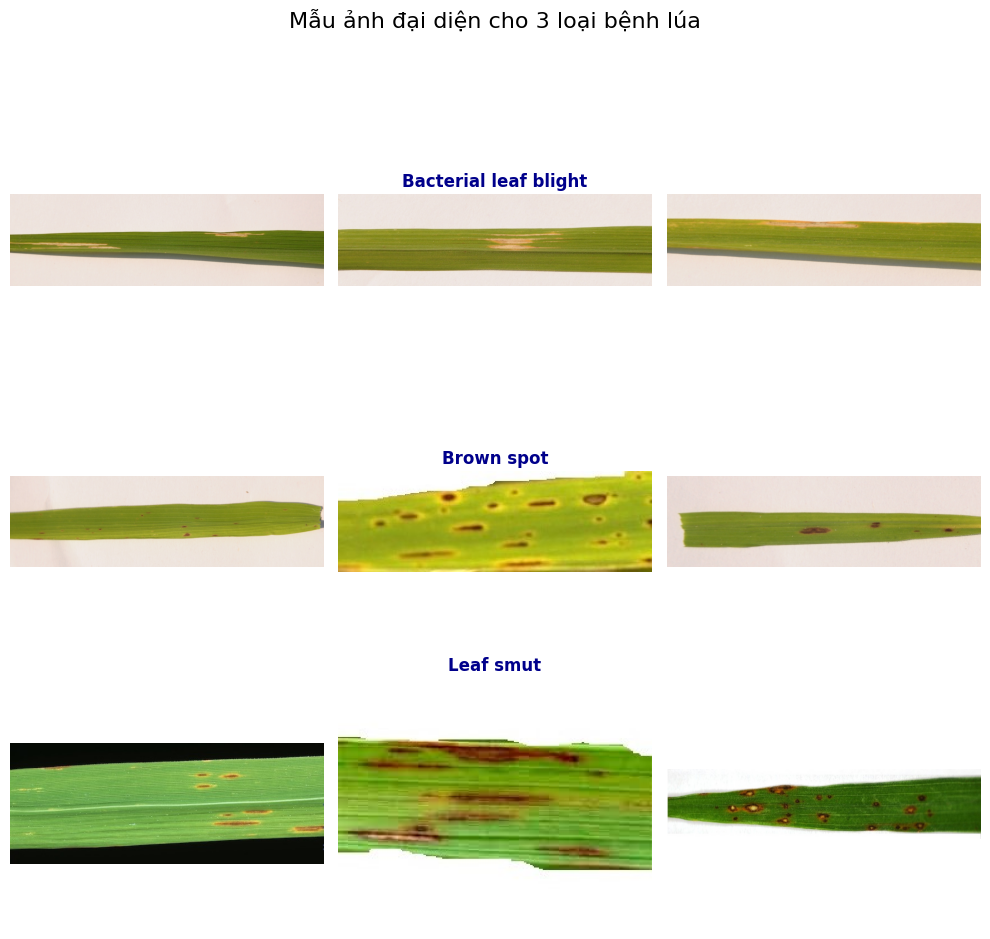


[B] Biểu đồ phân bố số lượng ảnh:


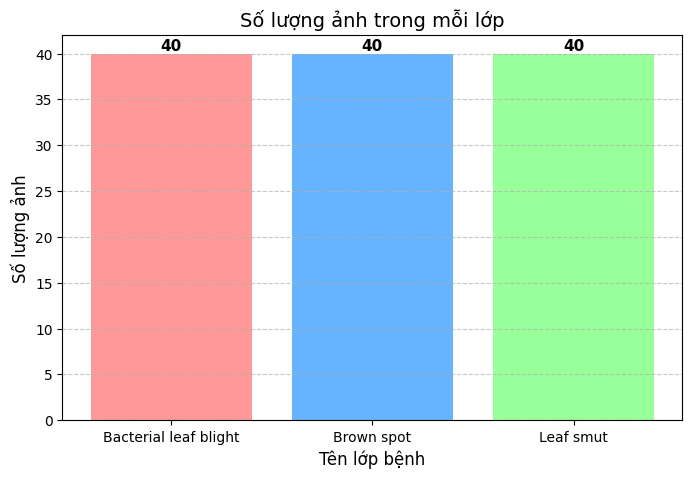


[C] Nhận xét: 
   o "Ảnh không đồng nhất về kích thước -> cần resize về 224x224."


In [ ]:
# Trực quan hóa và Nhận xét
print("\n" + "="*40)
print(">>> BIỂU ĐỒ & NHẬN XÉT")
print("="*40)

if len(data) > 0:
    # Vẽ Grid 3x3 ảnh mẫu
    print("\n[A] Grid 3x3 Ảnh mẫu (Đại diện từng lớp):")

    unique_classes = sorted(df['Class Name'].unique())

    # Tạo khung vẽ 3 hàng x 3 cột
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    fig.suptitle('Mẫu ảnh đại diện cho 3 loại bệnh lúa', fontsize=16)

    for i, c_name in enumerate(unique_classes):
        # Lấy index của 3 ảnh đầu tiên thuộc lớp này
        subset_indices = df[df['Class Name'] == c_name].index[:3]

        for j, idx in enumerate(subset_indices):
            if i < 3 and j < 3: # Đảm bảo không vượt quá lưới 3x3
                img_arr = data[idx]
                ax = axes[i, j]
                ax.imshow(img_arr)

                # Chỉ hiện tên lớp ở cột đầu tiên của mỗi hàng
                if j == 1:
                    ax.set_title(c_name, fontsize=12, fontweight='bold', color='darkblue')

                ax.axis('off') # Tắt trục tọa độ cho đẹp

    plt.tight_layout()
    plt.subplots_adjust(top=0.92) # Chừa chỗ cho tiêu đề lớn
    plt.show()

    # Biểu đồ cột số lượng ảnh mỗi lớp
    print("\n[B] Biểu đồ phân bố số lượng ảnh:")

    class_counts = df['Class Name'].value_counts().sort_index()

    plt.figure(figsize=(8, 5))
    bars = plt.bar(class_counts.index, class_counts.values, color=['#ff9999','#66b3ff','#99ff99'])

    plt.title('Số lượng ảnh trong mỗi lớp', fontsize=14)
    plt.xlabel('Tên lớp bệnh', fontsize=12)
    plt.ylabel('Số lượng ảnh', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Hiển thị số liệu cụ thể trên đầu mỗi cột
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height}',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.show()

    # Nhận xét kết quả
    print("\n[C] Nhận xét: ")

    # Kiểm tra độ lệch chuẩn của kích thước ảnh
    std_w = df['Width'].std()
    std_h = df['Height'].std()

    # In ra câu nhận xét
    conclusion_text = ""
    if std_w > 0 or std_h > 0:
        conclusion_text = "Ảnh không đồng nhất về kích thước -> cần resize về 224x224."
    else:
        input_shape = f"{df['Width'].iloc[0]}x{df['Height'].iloc[0]}"
        conclusion_text = f"Ảnh đã đồng nhất kích thước ({input_shape})."

    # In ra câu kết luận in nghiêng
    print(f"   o \"{conclusion_text}\"")

else:
    print("Chưa có dữ liệu để vẽ biểu đồ.")

**Giải thích cell 5: vẽ biểu đồ khám phá**
- Dòng 1 -> 4: in ra thông báo
- Dòng 6: kiểm tra điều kiện len(data): nếu có ảnh thì thực hiện chương trình.
- Dòng 10: lấy tên các lớp và sắp xếp theo thứ tự tăng đần để cố định thứ tự.
- Dòng 13: tạo lưới 3x3 bằng plt.subplots.
- Dòng 16 -> 30: Sử dụng vòng lặp for i, c_name in enumerate(unique_classes) để lấy 3 ảnh đầu tiên của mỗi lớp.
- Dòng 20 -> 34: hiển thị ảnh vào dúng ô và căn chỉnh format.
- Dòng 36 -> 47: vẽ biểu đồ cột.
- Dòng 49 -> 59: gắn nhãn và sử dụng vòng lặp for để thực hiện hiển thị số lượng trên đầu cột, sau đó in ra thông báo nhận xét.
- Dòng 61 -> 63: tính độ lệch chuẩn std = df['...'].std(), nếu std > 0 thì kích thước ảnh không đồng nhất.
- Dòng 65 -> 77: in ra nhận xét.

In [ ]:
# Xử lý giá trị ngoại lai (Outliers)
print("\n" + "="*40)
print(">>> XỬ LÝ OUTLIERS (INTENSITY)")
print("="*40)

if len(data) > 0 and 'Mean Intensity' in df.columns:

    # 1. Tính toán IQR cho Mean Intensity
    Q1 = df['Mean Intensity'].quantile(0.25)
    Q3 = df['Mean Intensity'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Thực hiện lọc dữ liệu
    # Giữ lại những dòng nằm trong khoảng an toàn
    df_clean = df[(df['Mean Intensity'] >= lower_bound) & (df['Mean Intensity'] <= upper_bound)]

    # Các dòng bị loại bỏ
    outliers_removed = df[~((df['Mean Intensity'] >= lower_bound) & (df['Mean Intensity'] <= upper_bound))]

    num_removed = len(df) - len(df_clean)

    print(f"- Số lượng mẫu ban đầu: {len(df)}")
    print(f"- Số lượng mẫu sau khi xử lý: {len(df_clean)}")
    print(f"- Số lượng Outliers đã loại bỏ: {num_removed}")

    if num_removed > 0:
        print("=> Hình ảnh các mẫu bị loại bỏ (Quá tối hoặc quá sáng):")

        num_show = num_removed # 1. Lấy hết số lượng outlier
        cols = 5
        rows = (num_show // cols) + (1 if num_show % cols > 0 else 0)
        plt.figure(figsize=(15, 3 * rows))
        outlier_indices = outliers_removed.index

        for i, idx in enumerate(outlier_indices):
            try:
                img_arr = data[idx]
                file_name = df.loc[idx, 'File Name']
                intensity = df.loc[idx, 'Mean Intensity']

                plt.subplot(rows, cols, i + 1)
                plt.imshow(img_arr)
                plt.title(f"{file_name}\nVal: {intensity:.1f}", fontsize=9, color='red')
                plt.axis('off')
            except:
                pass

        plt.tight_layout()
        plt.show()
        # -------------------------------------------------

    else:
        print("=> Dữ liệu tốt, không cần loại bỏ mẫu nào.")


else:
    print("Chưa có thông tin Intensity để xử lý.")

**Giải thích cell 6: loại bỏ outliers**
- Dòng 2 -> 4: in ra thông báo.
- Dòng 6: kiểm tra điều kiện len(data) và cột Mean Intensity: nếu có ảnh và cột Mean Intensity thì thực hiện chương trình.
- Dòng 8 -> 11: tính toán IQR cho Mean Intensity.
- Dòng 13 -> 14: tính ngưỡng để xác định Outliers:
1.   Intensity < lower_bound (quá tối)
2.   Intensity > upper_bound (quá sáng)
- Dòng 16 -> 23: thực hiện lọc dữ liệu và tách các outliers.
- Dòng 25 -> 27: in ra thông báo số lượng mẫu ban đầu, sau khi xử lý và outliers đã bị loại bỏ.
- Dòng 29 -> 52: nếu tồn tại outlies thì in ra các hình đó.
- Dòng 55 -> 60: in ra các thông báo của điều kiện.